## Bayesian Causal Forest for HTE
**Model**: BCF for log-rate outcomes (normal on log-rate): model baseline log-rate μ(X) and treatment effect surface τ(X) with treatment A and include PS p(X) (or logit PS) as a covariate to correct for targeted selection.

To model BART with a count outcome treat as a GLM with the additional terms of a log offset and overdispersion term from the Negative Binomial.
$$Y_i \sim \text{NegativeBinomial}(\mu = \lambda_i, \alpha)$$
$$\log(\lambda_i) = \log(\text{offset}_i) + \mu(x_i, \hat{p}) + \tau(x_i) \cdot T_i$$
where $\alpha$ is the overdispersion term and *offset* is the follow-time per patient
- $\mu(x_i, \pi_i)$ = the **prognostic function** — captures baseline outcome risk, regardless of treatment. $\pi_i$ are the propensity score estimates.
- $\tau(x_i)$ = the **treatment effect function** — captures how the treatment effect varies with covariates (this is CATE)
- $A \in {0,1}$ is the treatment indicator

In [1]:
import os
import sys
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree
from scipy.stats import norm, t
import pymc as pm
import pymc_bart as pmb
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
rng = np.random.default_rng(123)

output_folder = "ISYE6420/Project/"
import ISYE6420.Project.visualisations as vis

## Data Loading and Preparation

In [2]:
# Import configurations
dx_name = "asthma"
version = "v7_040226"

cohort = pd.read_csv(f"ISYE6420\\Project\\data\\{dx_name}_weighted_cohort.csv")
print(len(cohort))

18022


In [3]:
y = cohort["outcome"].values
treatment = cohort["exposure"].values
follow_up_time = cohort["follow_up_time"].values
y_data = y.copy()

### 1. Prognostic Model $\mu(X, \hat{p})$

In [4]:
X = cohort.drop(columns=["patid", "outcome", "exposure", "follow_up_time", "weight", "ps_score"])
# convert True False columns to int
X = X.astype(int)
# Logit transform the propensity scores for better modeling
propensity_score = cohort["ps_score"]
eps = 1e-6
ps_values = np.clip(propensity_score, eps, 1 - eps)
logit_ps = np.log(ps_values / (1 - ps_values))
X['logit_ps'] = logit_ps
X_mu = X.values

prognostic_model_config = {
    "n_trees": 200,
    "beta_prior": 2,
    "alpha_prior": 0.95,
}

In [5]:
num_exac_pats = cohort[cohort['outcome'] > 0]['patid'].nunique()/ cohort['patid'].nunique()
print(f"Proportion of patients with at least one event: {num_exac_pats:.2%}")

Proportion of patients with at least one event: 4.98%


In [6]:
num_exac_pats

0.04980157621150299

In [7]:
X.columns

Index(['age', 'gina_step', 'total_exac_count', 'num_treatments_baseline',
       'num_outpatient_event', 'num_er_event', 'hba1c_missing',
       'atopic_disease_flag', 'ckd_flag', 'dyslipidemia_flag',
       'eosinophilic_disease_flag', 'heart_failure_flag', 'hypertension_flag',
       'ischemic_stroke_flag', 'nasal_polyps_flag',
       'obstructive_sleep_apnea_flag', 't2dm_flag', 'bmi_20_25',
       'bmi_above_25', 'bmi_present', 'Acute_IHD_flag', 'CAD_flag', 'PVD_flag',
       'Biologics_flag', 'ICS_flag', 'ICS_LABA_flag', 'ICS_LABA_LAMA_flag',
       'LTRA_flag', 'OCS_flag', 'SABA_flag', 'SABA_SAMA_flag', 'sex_Female',
       'region_Midwest', 'region_Northeast', 'region_South',
       'region_Southwest', 'region_West', 'logit_ps'],
      dtype='str')

### 2. $\tau$(X) Treatment Effect Model

The treatment BART is fitted on the **residual** after subtracting the posterior mean of μ.
Only **treated** patients contribute signal to τ — we restrict to T=1 for the fit,
then predict τ for everyone to compute CATTs.

In [8]:
# Treatment indicator as int
T = treatment.astype(int)

# Feature matrix for tau: same covariates as mu, but add treatment indicator instead of propensity score
X["T"] = T
X_tau = X.values.astype(float)

tau_model_config = {
    "n_trees": 25,       # stronger regularisation toward zero for treatment effects
    "beta_prior": 3,     # more shrinkage towards homogenenous treatment effects
    "alpha_prior": 0.25,
}


## Full Joint BCF Model

New model specification with intercept:
$$log(Y_i) = \mu(x_i, \pi_i) + \tau(x_i) \cdot T_i + log(\text{offset}) + I+\epsilon_i$$
where the intercept, $I \sim N(-3, 0.5)$


Implementation in PyMC ($\epsilon$ already present in model)
$$log(Y) = X_{\mu} + X_{\tau} + log(\text{offset}) +I$$

- $X_\mu$ = full covariates + logit_ps
- $X_\tau$ = full covariates + treatment indicator T

In [9]:
with pm.Model() as bcf_joint:

    X_mu_shared  = pm.Data("X_mu",  X_mu)
    X_tau_shared = pm.Data("X_tau", X_tau)
    T_shared = pm.Data("T", T.astype(float))
    y_obs = pm.Data("y_obs", y_data)
    offset = pm.Data("offset", follow_up_time)

    # Prognosis model
    mu = pmb.BART(
        "mu",
        X_mu_shared,
        y_data,
        m=prognostic_model_config["n_trees"],
        alpha=prognostic_model_config["alpha_prior"],
        beta=prognostic_model_config["beta_prior"],
        response="constant"
    )

    # Treatment effect
    tau = pmb.BART(
        "tau",
        X_tau_shared,
        y_data,
        m=tau_model_config["n_trees"],
        alpha=tau_model_config["alpha_prior"],
        beta=tau_model_config["beta_prior"],
        response="constant"
    )
    # Add constant intercept
    constant_intercept = norm.ppf(round(num_exac_pats, 2))
    # Log-link with offset
    lambda_ = pm.Deterministic("lambda_", mu + tau * T_shared + np.log(offset) + constant_intercept)
    # Overdispertion term
    kappa = pm.Exponential("kappa", lam=1)

    # Likelihood as a negative binomial for count data
    y_likelihood = pm.NegativeBinomial("y_likelihood", mu=pm.math.exp(lambda_), alpha=kappa, observed=y_obs)

    trace_bcf = pm.sample(2000, tune=6000, random_seed=rng, chains=4, target_accept=0.9)

ppc = pm.sample_posterior_predictive(trace_bcf, model=bcf_joint)
az.summary(trace_bcf, var_names=["kappa"], round_to=3, hdi_prob=0.95)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>CompoundStep
>>PGBART: [mu]
>>PGBART: [tau]
>NUTS: [kappa]


Output()

Sampling 4 chains for 6_000 tune and 2_000 draw iterations (24_000 + 8_000 draws total) took 11409 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_likelihood]


Output()

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
kappa,0.766,0.131,0.533,1.029,0.002,0.002,2891.627,3675.912,1.0


In [10]:
az.to_netcdf(trace_bcf, f"{output_folder}bcf_{dx_name}_exac.nc")

'ISYE6420/Project/bcf_asthma_exac.nc'

In [11]:
# Extract CATTs from joint model
mu_joint  = trace_bcf.posterior["mu"].mean(dim=["chain", "draw"]).values
tau_joint = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values
tau_joint_sd = trace_bcf.posterior["tau"].std(dim=["chain", "draw"]).values

print(f"Joint CATT summary — mean: {tau_joint.mean():.4f}, sd: {tau_joint.std():.4f}")
print(f"ATT (treated only): {tau_joint[T == 1].mean():.4f}")

Joint CATT summary — mean: -0.0359, sd: 0.0552
ATT (treated only): -0.0302


array([[<Axes: title={'center': 'kappa'}>,
        <Axes: title={'center': 'kappa'}>]], dtype=object)

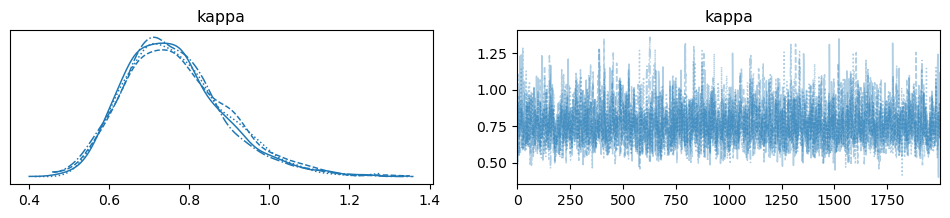

In [12]:
az.plot_trace(trace_bcf, var_names=["kappa"])

In [13]:
summary = az.summary(trace_bcf, var_names=["tau"], filter_vars="like")
print(summary[summary["r_hat"] > 1.01].head(20))
print(f"\nMedian ESS (bulk): {summary['ess_bulk'].median():.0f}")
print(f"Patients with ESS < 100: {(summary['ess_bulk'] < 100).sum()}")

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau[0]  -0.021  0.107  -0.226    0.168      0.008    0.002     194.0   
tau[1]   0.056  0.107  -0.145    0.255      0.010    0.003     117.0   
tau[2]  -0.051  0.114  -0.256    0.182      0.013    0.003      73.0   
tau[3]   0.015  0.115  -0.200    0.230      0.016    0.003      53.0   
tau[4]  -0.027  0.119  -0.259    0.181      0.024    0.003      24.0   
tau[5]  -0.023  0.102  -0.210    0.171      0.004    0.002     587.0   
tau[6]   0.005  0.110  -0.187    0.217      0.014    0.003      62.0   
tau[7]  -0.030  0.113  -0.245    0.178      0.014    0.003      66.0   
tau[8]  -0.024  0.109  -0.227    0.177      0.004    0.002     666.0   
tau[9]  -0.079  0.107  -0.277    0.128      0.005    0.003     510.0   
tau[10] -0.035  0.110  -0.241    0.167      0.014    0.003      65.0   
tau[11] -0.057  0.105  -0.252    0.142      0.005    0.002     495.0   
tau[12] -0.053  0.109  -0.251    0.152      0.005    0.002     4

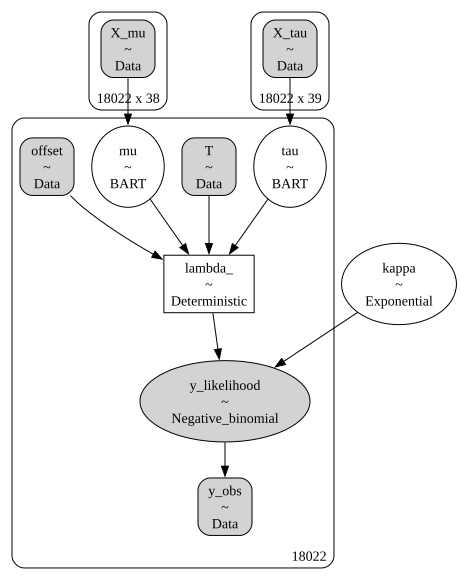

In [14]:
# create DAG
pm.model_to_graphviz(bcf_joint)

## Outcome Analysis

In [ ]:
# Load trace from nc file
# trace_bcf = az.from_netcdf(f"{output_folder}bcf_{dx_name}_severe.nc")

In [ ]:
# with pm.Model() as bcf_joint:
#     # Re-declare data containers
#     X_mu_shared = pm.Data("X_mu", X_mu)
#     X_tau_shared = pm.Data("X_tau", X_tau)
#     T_shared = pm.Data("T", T.astype(float))
#     y_obs = pm.Data("y_obs", y_data)
#     offset = pm.Data("offset", follow_up_time)

#     # Re-declare the BART and parameters
#     mu = pmb.BART(
#         "mu",
#         X_mu_shared,
#         y_data,
#         m=prognostic_model_config["n_trees"],
#         alpha=prognostic_model_config["alpha_prior"],
#         beta=prognostic_model_config["beta_prior"],
#         response="constant"
#     )

#     # Treatment effect
#     tau = pmb.BART(
#         "tau",
#         X_tau_shared,
#         y_data,
#         m=tau_model_config["n_trees"],
#         alpha=tau_model_config["alpha_prior"],
#         beta=tau_model_config["beta_prior"],
#         response="constant"
#     )
#     constant_intercept = norm.ppf(round(num_exac_pats, 2)) 
#     lambda_ = pm.Deterministic("lambda_", mu + tau * T_shared + np.log(offset) + constant_intercept)
#     kappa = pm.Exponential("kappa", lam=1)
    
#     y_likelihood = pm.NegativeBinomial(
#         "y_likelihood", 
#         mu=pm.math.exp(lambda_), 
#         alpha=kappa, 
#         observed=y_obs
#     )

# # Now you can run PPC using the trace loaded from the .nc file
# with bcf_joint:
#     ppc = pm.sample_posterior_predictive(trace_bcf)

## Diagnostic Workflow

In [15]:
zero_ppc = (ppc.posterior_predictive["y_likelihood"] == 0).mean(dim=["chain", "draw"])
print(zero_ppc.values.mean())  # compare to actual zero rate

0.9501492550771279


BFMI < 0.3 indicates potential issues with sampler efficiency.


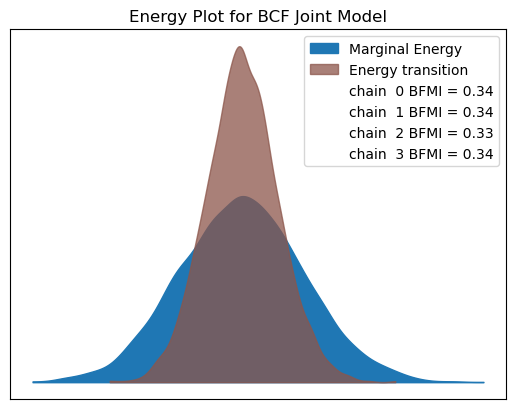

In [16]:
# Check Sampler efficiency through energy plot
print("BFMI < 0.3 indicates potential issues with sampler efficiency.")
energy_ax = az.plot_energy(trace_bcf)
energy_ax.set_title("Energy Plot for BCF Joint Model")
plt.show()

## Goodness of Fit Check

Text(0.5, 1.0, 'Comparison in Log-Space')

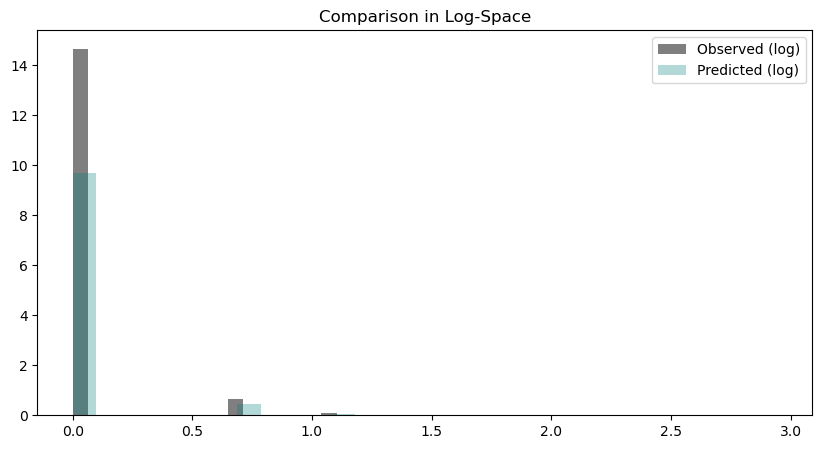

In [17]:
# Manually plot the log of the observed vs predicted
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(y_data), bins=30, density=True, alpha=0.5, label="Observed (log)", color="black")

# Pull a few samples from the posterior predictive
pp_counts = ppc.posterior_predictive["y_likelihood"].values.flatten()
plt.hist(np.log1p(pp_counts), bins=30, density=True, alpha=0.3, label="Predicted (log)", color="teal")

plt.legend()
plt.title("Comparison in Log-Space")

Text(0.5, 1.0, 'Distribution of Log-Likelihood (lambda_)')

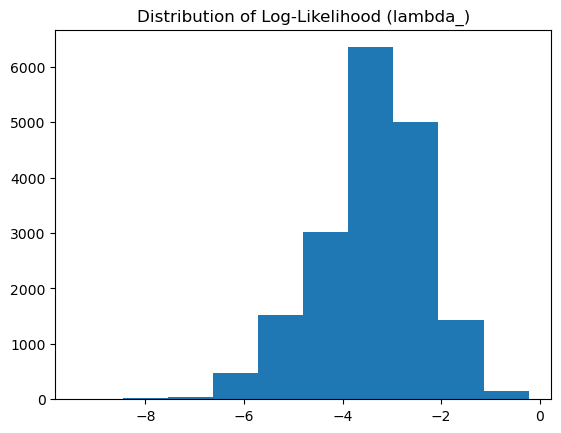

In [18]:
# Check the mean of your predicted lambda before the exponential
plt.hist(trace_bcf.posterior["lambda_"].mean(dim=["chain", "draw"]).values.flatten())
plt.title("Distribution of Log-Likelihood (lambda_)")

## Visualising Treatment Effects

Text(0.5, 1.0, 'Distribution of Individual Treatment Effects')

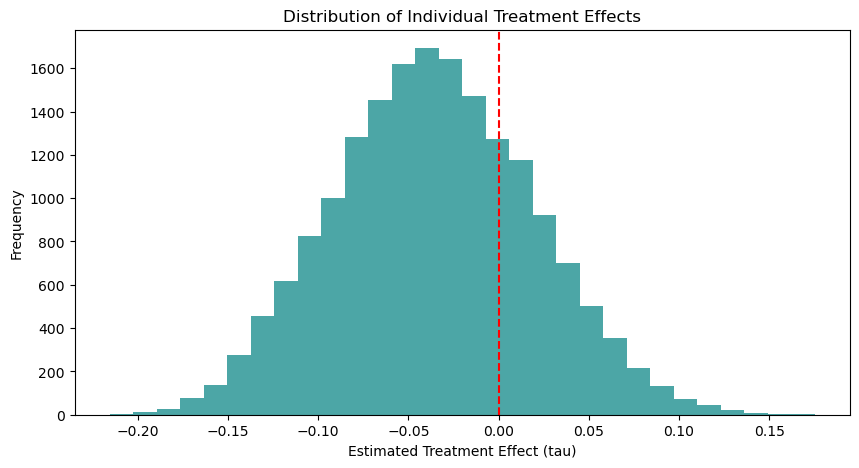

In [19]:
# Visualize the distribution of the Individual Treatment Effects (ITE)
# We take the mean of tau across the posterior samples for each observation
ite_means = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"])

plt.figure(figsize=(10, 5))
plt.hist(ite_means, bins=30, color="teal", alpha=0.7)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Estimated Treatment Effect (tau)")
plt.ylabel("Frequency")
plt.title("Distribution of Individual Treatment Effects")

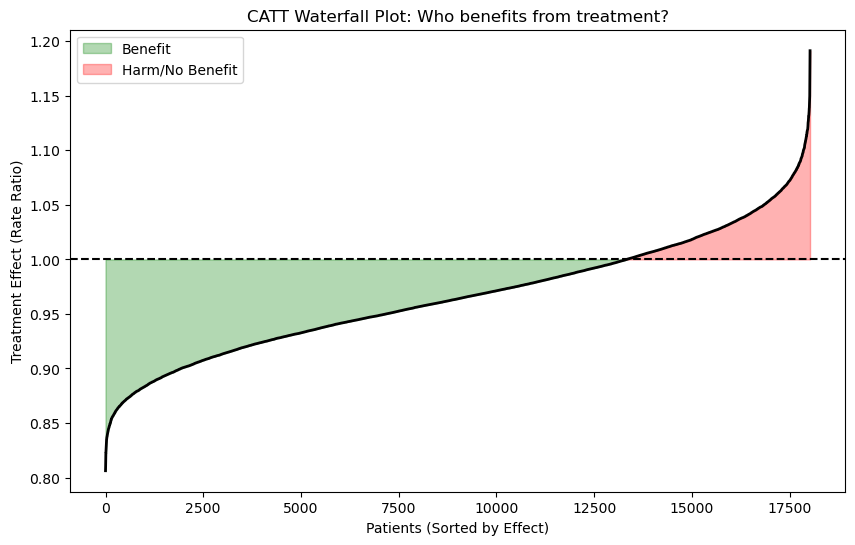

In [20]:
# 1. Get the mean Tau for each of the 20,500 observations
# We convert to Rate Ratio (exp) for the Y-axis
catt_estimates = np.exp(trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values)

# 2. Sort them
sorted_catt = np.sort(catt_estimates)
index = np.arange(len(sorted_catt))

plt.figure(figsize=(10, 6))
plt.fill_between(index, 1, sorted_catt, where=(sorted_catt < 1), color='green', alpha=0.3, label='Benefit')
plt.fill_between(index, 1, sorted_catt, where=(sorted_catt > 1), color='red', alpha=0.3, label='Harm/No Benefit')
plt.plot(index, sorted_catt, color='black', linewidth=2)
plt.axhline(1, color='black', linestyle='--')
plt.ylabel("Treatment Effect (Rate Ratio)")
plt.xlabel("Patients (Sorted by Effect)")
plt.title("CATT Waterfall Plot: Who benefits from treatment?")
plt.legend()
plt.show()

C:\Users\nedee\AppData\Local\Temp\ipykernel_14068\259882038.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary_stats.index, y=summary_stats.values, palette="mako")


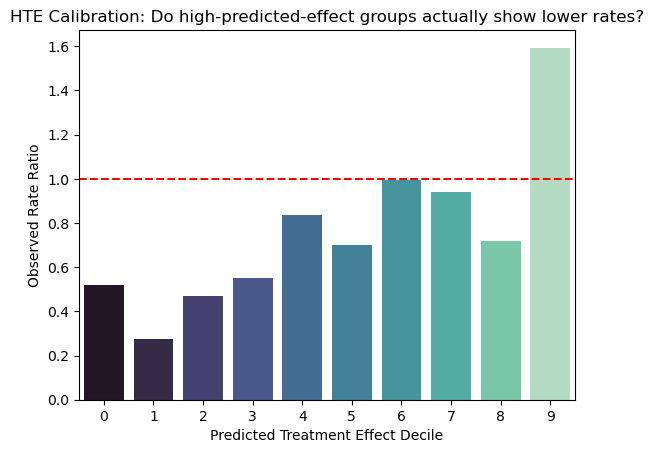

In [21]:
# Create a DataFrame with predicted tau and actual outcomes
df_eval = pd.DataFrame({
    'pred_tau': catt_estimates,
    'observed_y': y_data,
    'T': T
})

# Bin by predicted effect deciles
df_eval['decile'] = pd.qcut(df_eval['pred_tau'], 10, labels=False)

# Calculate observed Rate Ratio per decile
# (Rate in Treated / Rate in Control)
summary_stats = df_eval.groupby('decile').apply(
    lambda x: (x[x['T']==1]['observed_y'].mean()) / (x[x['T']==0]['observed_y'].mean())
)

sns.barplot(x=summary_stats.index, y=summary_stats.values, palette="mako")
plt.axhline(1, color='red', linestyle='--')
plt.ylabel("Observed Rate Ratio")
plt.xlabel("Predicted Treatment Effect Decile")
plt.title("HTE Calibration: Do high-predicted-effect groups actually show lower rates?")
plt.show()

## Interpretable Outputs

In [22]:
def get_tau_samples(trace):
    """Flatten posterior tau samples → (total_draws, N)"""
    tau = trace.posterior["tau"].values          # (chains, draws, N)
    return tau.reshape(-1, tau.shape[-1])        # (4000, N)

def cate_summary(tau_flat, idx):
    """Return (mean, lo94, hi94, P(tau>0)) for a subgroup index array."""
    draws = tau_flat[:, idx].mean(axis=1)        # (total_draws,) — CATE posterior
    hdi = az.hdi(draws, hdi_prob=0.94)
    return draws.mean(), hdi[0], hdi[1], (draws > 0).mean()

In [23]:
# 1. Individual Level IRRs
tau_samples = get_tau_samples(trace_bcf) 
irr_samples = np.exp(tau_samples)

# Calculate Posterior Mean and 95% HDI for each patient
irr_mean = irr_samples.mean(axis=(0, 1))
irr_hdi = az.hdi(irr_samples, hdi_prob=0.95)

# 2. Overall CATT (on log-rate scale first, then summarized)
# Filter tau for treated patients only (T=1)
treated_indices = np.where(T == 1)[0]
catt_samples = tau_samples[:, treated_indices].mean(axis=1)  # (total_draws,) — CATT posterior for treated

catt_mean = catt_samples.mean()
catt_hdi = az.hdi(catt_samples, hdi_prob=0.95)

print(f"Overall CATT (log-scale): {catt_mean:.3f} 95% HDI {catt_hdi}")
print(f"Overall CATT (IRR scale): {np.exp(catt_mean):.3f}")

C:\Users\nedee\AppData\Local\Temp\ipykernel_14068\2133956032.py:7: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  irr_hdi = az.hdi(irr_samples, hdi_prob=0.95)


Overall CATT (log-scale): -0.030 95% HDI [-0.13145768  0.0741505 ]
Overall CATT (IRR scale): 0.970


In [24]:
tau_flat    = tau_samples.reshape(-1, tau_samples.shape[-1])  # (4000, N)
att_draws = tau_flat[:, treated_indices].mean(axis=1)
print(f"ATT ESS: {az.ess(att_draws):.0f}")
print(f"ATT Rhat: {az.rhat(att_draws.reshape(4, -1)):.4f}")

ATT ESS: 803
ATT Rhat: 1.0039


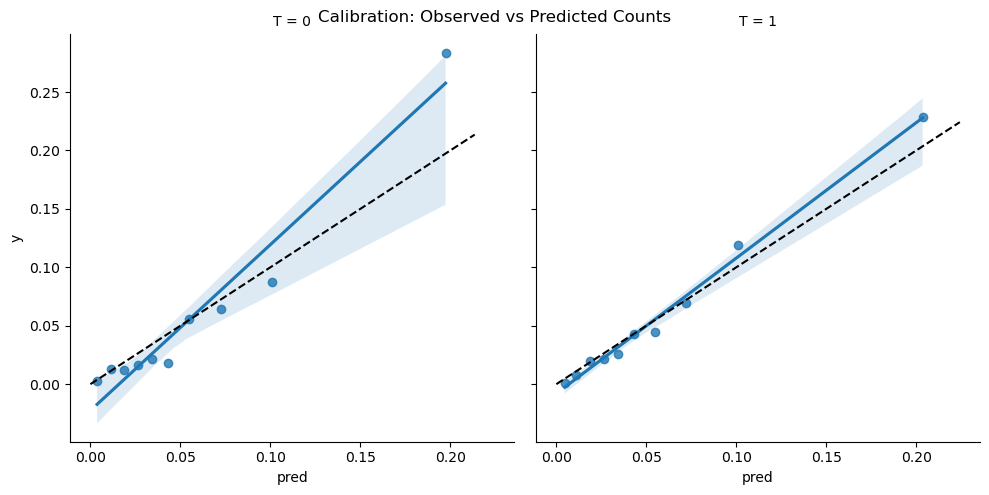

In [25]:
y_pred_mean = ppc.posterior_predictive["y_likelihood"].mean(axis=(0, 1)).values

def plot_calibration(y_true, y_pred, treatment, title):
    df_cal = pd.DataFrame({'y': y_true, 'pred': y_pred, 'T': treatment})
    df_cal['decile'] = pd.qcut(df_cal['pred'], 10, labels=False, duplicates='drop')
    
    cal_data = df_cal.groupby(['T', 'decile']).agg({'y': 'mean', 'pred': 'mean'}).reset_index()
    
    sns.lmplot(data=cal_data, x='pred', y='y', col='T')
    for ax in plt.gcf().axes:
        ax.plot([0, ax.get_xlim()[1]], [0, ax.get_xlim()[1]], 'k--')
    plt.suptitle(title)

plot_calibration(y_data, y_pred_mean, T, "Calibration: Observed vs Predicted Counts")

In [26]:
# ── Extract posterior tau samples ────────────────────────────────────────────
# Shape: (chains, draws, n_obs) → flatten to (draws_total, n_obs)
tau_samples = trace_bcf.posterior["tau"].values          # (4, 1000, N)
tau_flat    = tau_samples.reshape(-1, tau_samples.shape[-1])  # (4000, N)
tau_mean    = tau_flat.mean(axis=0)                      # (N,)
tau_hdi     = az.hdi(tau_flat, hdi_prob=0.95)            # (N, 2)

mu_samples  = trace_bcf.posterior["mu"].values
mu_flat     = mu_samples.reshape(-1, mu_samples.shape[-1])
mu_mean     = mu_flat.mean(axis=0)

# Separate treated / control
treated_idx  = np.where(T == 1)[0]
control_idx  = np.where(T == 0)[0]

ATT = tau_flat[:, treated_idx].mean(axis=1)   # (draws,) — ATT distribution
ATE = tau_flat.mean(axis=1)                   # (draws,) — ATE distribution

C:\Users\nedee\AppData\Local\Temp\ipykernel_14068\1250611759.py:6: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  tau_hdi     = az.hdi(tau_flat, hdi_prob=0.95)            # (N, 2)


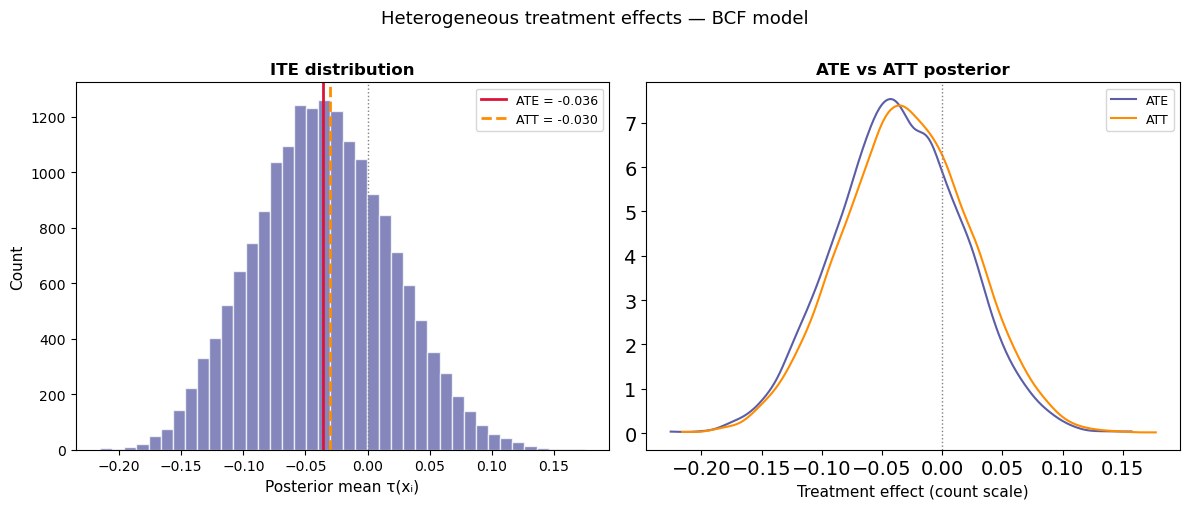

In [27]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1 — ITE distribution + ATT/ATE summary
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: histogram of posterior-mean ITEs
ax = axes[0]
ax.hist(tau_mean, bins=40, color="#5B5EA6", alpha=0.75, edgecolor="white")
ax.axvline(tau_mean.mean(), color="crimson", lw=2, label=f"ATE = {tau_mean.mean():.3f}")
ax.axvline(tau_mean[treated_idx].mean(), color="darkorange", lw=2,
           linestyle="--", label=f"ATT = {tau_mean[treated_idx].mean():.3f}")
ax.axvline(0, color="gray", lw=1, linestyle=":")
ax.set_xlabel("Posterior mean τ(xᵢ)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("ITE distribution", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

# Right: ATE vs ATT posterior distributions
ax = axes[1]
az.plot_dist(ATE, label="ATE", color="#5B5EA6", ax=ax)
az.plot_dist(ATT, label="ATT", color="darkorange", ax=ax)
ax.axvline(0, color="gray", lw=1, linestyle=":")
ax.set_xlabel("Treatment effect (count scale)", fontsize=11)
ax.set_title("ATE vs ATT posterior", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

fig.suptitle("Heterogeneous treatment effects — BCF model", fontsize=13, y=1.01)
fig.tight_layout()
#plt.savefig("fig1_ite_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

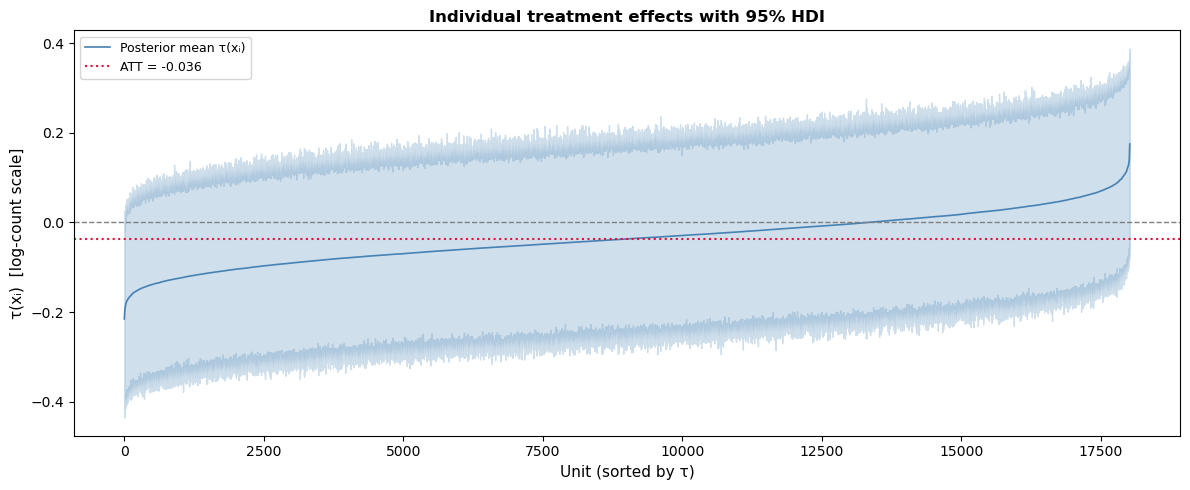

In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Credible-interval caterpillar plot (sorted by τ mean)
# ═══════════════════════════════════════════════════════════════════════════
sort_idx = np.argsort(tau_mean)
tau_sorted_mean = tau_mean[sort_idx]
tau_sorted_lo   = tau_hdi[sort_idx, 0]
tau_sorted_hi   = tau_hdi[sort_idx, 1]

fig, ax = plt.subplots(figsize=(12, 5))
n = len(tau_sorted_mean)
xs = np.arange(n)

ax.fill_between(xs, tau_sorted_lo, tau_sorted_hi, alpha=0.25, color="steelblue")
ax.plot(xs, tau_sorted_mean, lw=1.2, color="steelblue", label="Posterior mean τ(xᵢ)")
ax.axhline(0, color="gray", lw=1, linestyle="--")
ax.axhline(tau_mean.mean(), color="crimson", lw=1.5, linestyle=":", label=f"ATT = {tau_mean.mean():.3f}")
ax.set_xlabel("Unit (sorted by τ)", fontsize=11)
ax.set_ylabel("τ(xᵢ)  [log-count scale]", fontsize=11)
ax.set_title("Individual treatment effects with 95% HDI", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


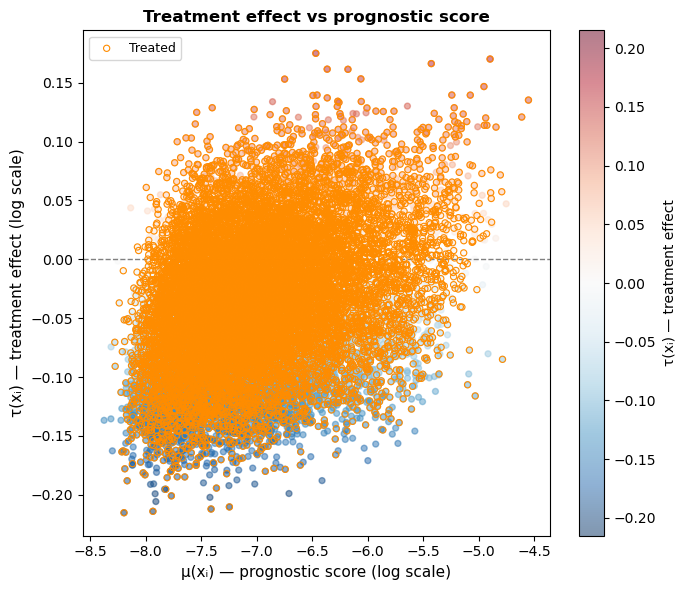

In [29]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(mu_mean, tau_mean, c=tau_mean, cmap="RdBu_r",
                alpha=0.5, s=18, vmin=-np.abs(tau_mean).max(), vmax=np.abs(tau_mean).max())
plt.colorbar(sc, ax=ax, label="τ(xᵢ) — treatment effect")
ax.axhline(0, color="gray", lw=1, linestyle="--")
ax.set_xlabel("μ(xᵢ) — prognostic score (log scale)", fontsize=11)
ax.set_ylabel("τ(xᵢ) — treatment effect (log scale)", fontsize=11)
ax.set_title("Treatment effect vs prognostic score", fontsize=12, fontweight="bold")
# Colour by treatment status for extra clarity
ax.scatter(mu_mean[treated_idx], tau_mean[treated_idx],
           s=20, edgecolors="darkorange", facecolors="none", lw=0.8, label="Treated", zorder=5)
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig("fig5_tau_vs_mu.png", dpi=150, bbox_inches="tight")
plt.show()

## Subgroup CATTs

Continuous features available for stratification: ['age', 'gina_step', 'total_exac_count', 'num_treatments_baseline', 'num_outpatient_event', 'num_er_event', 'logit_ps']


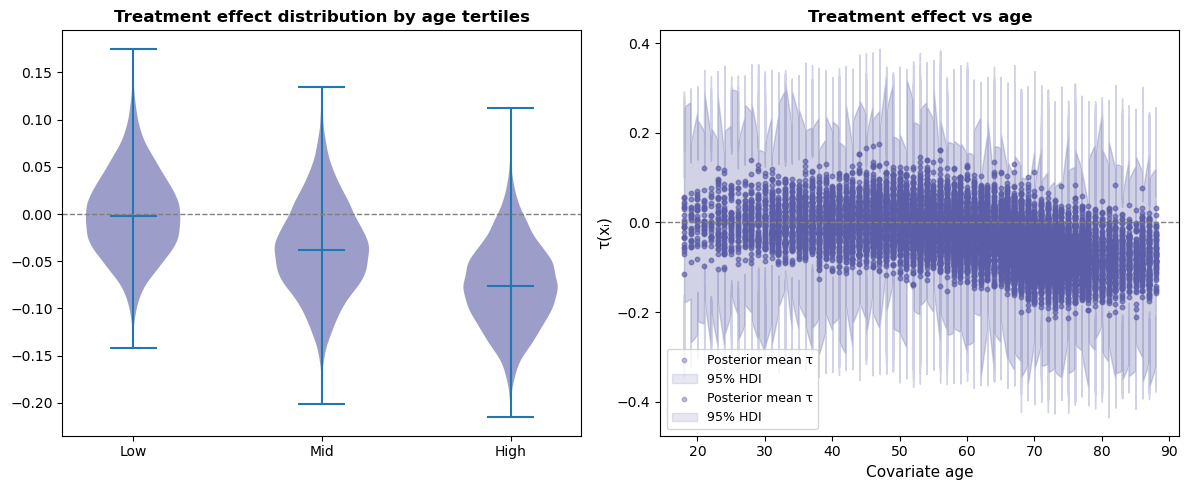

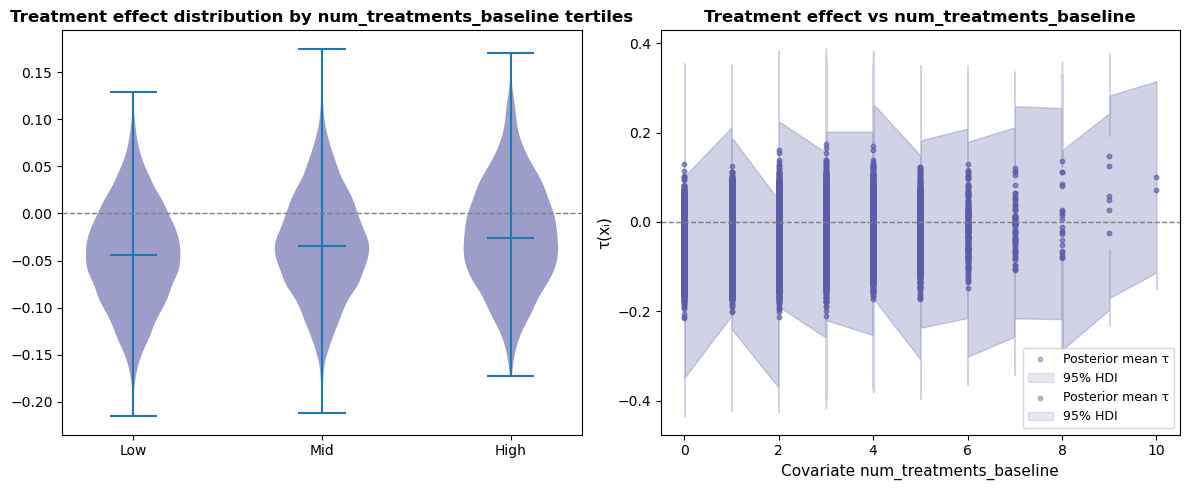

In [30]:
#from visualisations import plot_cate_by_feature
# Get all continuous features to stratify by (e.g. age, comorbidity count, etc.)
continuous_features = [col for col in X.columns if X[col].nunique() > 2 and X[col].dtype in [np.float64, np.int64]]
print("Continuous features available for stratification:", continuous_features)

# Do the same for total_exac_count but find quantile for patients with 1 event and quantile for patients with 2+ events
features_to_plot = ["age", "num_treatments_baseline"]
for feat in features_to_plot:
    vis.plot_CATT_by_feature(X, X_tau, tau_mean, tau_hdi, feat)
# # Find percentile where value is 1
# perc_1 = X[X['total_exac_count']==0].shape[0] / X.shape[0]
# perc_2 = X[X['total_exac_count']==1].shape[0] / X.shape[0] + perc_1

#vis.plot_CATT_by_feature(X, X_tau, tau_mean, tau_hdi, "total_exac_count", quants=[perc_1, perc_2])

(<Axes: title={'center': 'CATT by GINA Step'}, xlabel='CATT — posterior mean τ  [log-count scale]'>,
   level     n      mean      lo94      hi94      lo50      hi50     p_pos
 0     0  6921 -0.041277 -0.149557  0.060228 -0.080050 -0.003029  0.237375
 1     1  1910 -0.031501 -0.141698  0.067569 -0.063084  0.013205  0.293500
 2     2  2631 -0.037341 -0.135145  0.064166 -0.074834 -0.001557  0.249750
 3     3  1274 -0.039394 -0.138937  0.058809 -0.076115 -0.004144  0.233375
 4     4  2717 -0.037851 -0.134912  0.062135 -0.077036 -0.004265  0.243500
 5     5  2569 -0.019461 -0.123089  0.083182 -0.062749  0.011708  0.363625)

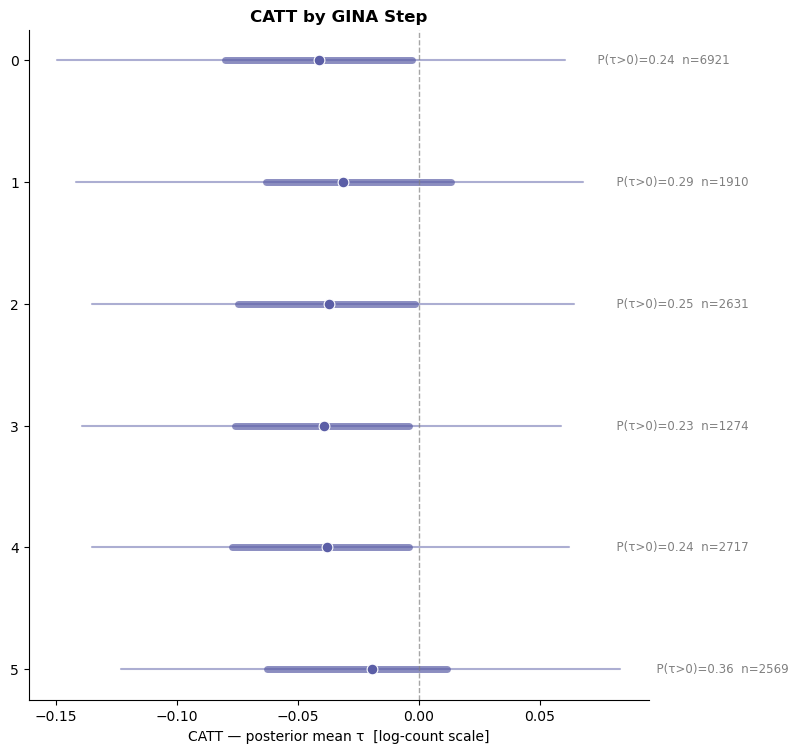

In [31]:
vis.plot_CATE_categorical(trace_bcf, X['gina_step'].to_numpy(), "GINA Step")

In [32]:
# Forest plot for multiple covariates
def plot_forest_multiple(trace, X, feature_names, ax=None, color="#5B5EA6"):
    """
    Parameters
    ----------
    covariate_array : 1-D array of category labels/codes for each covariate (e.g. age group, comorbidity count group, etc.)
    """
    tau_flat = get_tau_samples(trace)
    feature_idx = [X.columns.get_loc(col) for col in feature_names]
    rows = []
    for feat in feature_idx:
        covariate_array = X.iloc[:, feat].to_numpy()
        idx = np.where(covariate_array == 1)[0]
        mean, lo94, hi94, p_pos = cate_summary(tau_flat, idx)
        # Also compute 50% HDI for inner band
        draws_lv = tau_flat[:, idx].mean(axis=1)
        lo50, hi50 = az.hdi(draws_lv, hdi_prob=0.50)
        rows.append(dict(n=len(idx),
                         mean=mean, lo94=lo94, hi94=hi94,
                         lo50=lo50, hi50=hi50, p_pos=p_pos))

    df = pd.DataFrame(rows, index=feature_names)      

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 1.2 * len(df) + 1.5))

    y_pos = np.arange(len(df))[::-1]            # top = first level

    for i, (_, row) in enumerate(df.iterrows()):
        y = y_pos[i]
        # 94% HDI — thin line
        ax.plot([row.lo94, row.hi94], [y, y], lw=1.5,
                color=color, alpha=0.5, solid_capstyle="round")
        # 50% HDI — thick line
        ax.plot([row.lo50, row.hi50], [y, y], lw=5,
                color=color, alpha=0.7, solid_capstyle="round")
        # Posterior mean dot
        ax.scatter(row["mean"], y, s=60, color=color,
                   zorder=5, edgecolors="white", linewidths=0.8)
        # P(τ > 0) annotation on right
        ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] != 0 else row.hi94 + 0.01,
                y, f"  P(τ>0)={row.p_pos:.2f}  n={row.n}",
                va="center", fontsize=8.5, color="gray")

    ax.axvline(0, color="gray", lw=1, linestyle="--", alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df.index, fontsize=10)
    ax.set_xlabel("CATT — posterior mean τ  [log-count scale]", fontsize=10)
    ax.set_title(f"CATT by Multiple Covariates", fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    return ax, df

In [33]:
X.columns

Index(['age', 'gina_step', 'total_exac_count', 'num_treatments_baseline',
       'num_outpatient_event', 'num_er_event', 'hba1c_missing',
       'atopic_disease_flag', 'ckd_flag', 'dyslipidemia_flag',
       'eosinophilic_disease_flag', 'heart_failure_flag', 'hypertension_flag',
       'ischemic_stroke_flag', 'nasal_polyps_flag',
       'obstructive_sleep_apnea_flag', 't2dm_flag', 'bmi_20_25',
       'bmi_above_25', 'bmi_present', 'Acute_IHD_flag', 'CAD_flag', 'PVD_flag',
       'Biologics_flag', 'ICS_flag', 'ICS_LABA_flag', 'ICS_LABA_LAMA_flag',
       'LTRA_flag', 'OCS_flag', 'SABA_flag', 'SABA_SAMA_flag', 'sex_Female',
       'region_Midwest', 'region_Northeast', 'region_South',
       'region_Southwest', 'region_West', 'logit_ps', 'T'],
      dtype='str')

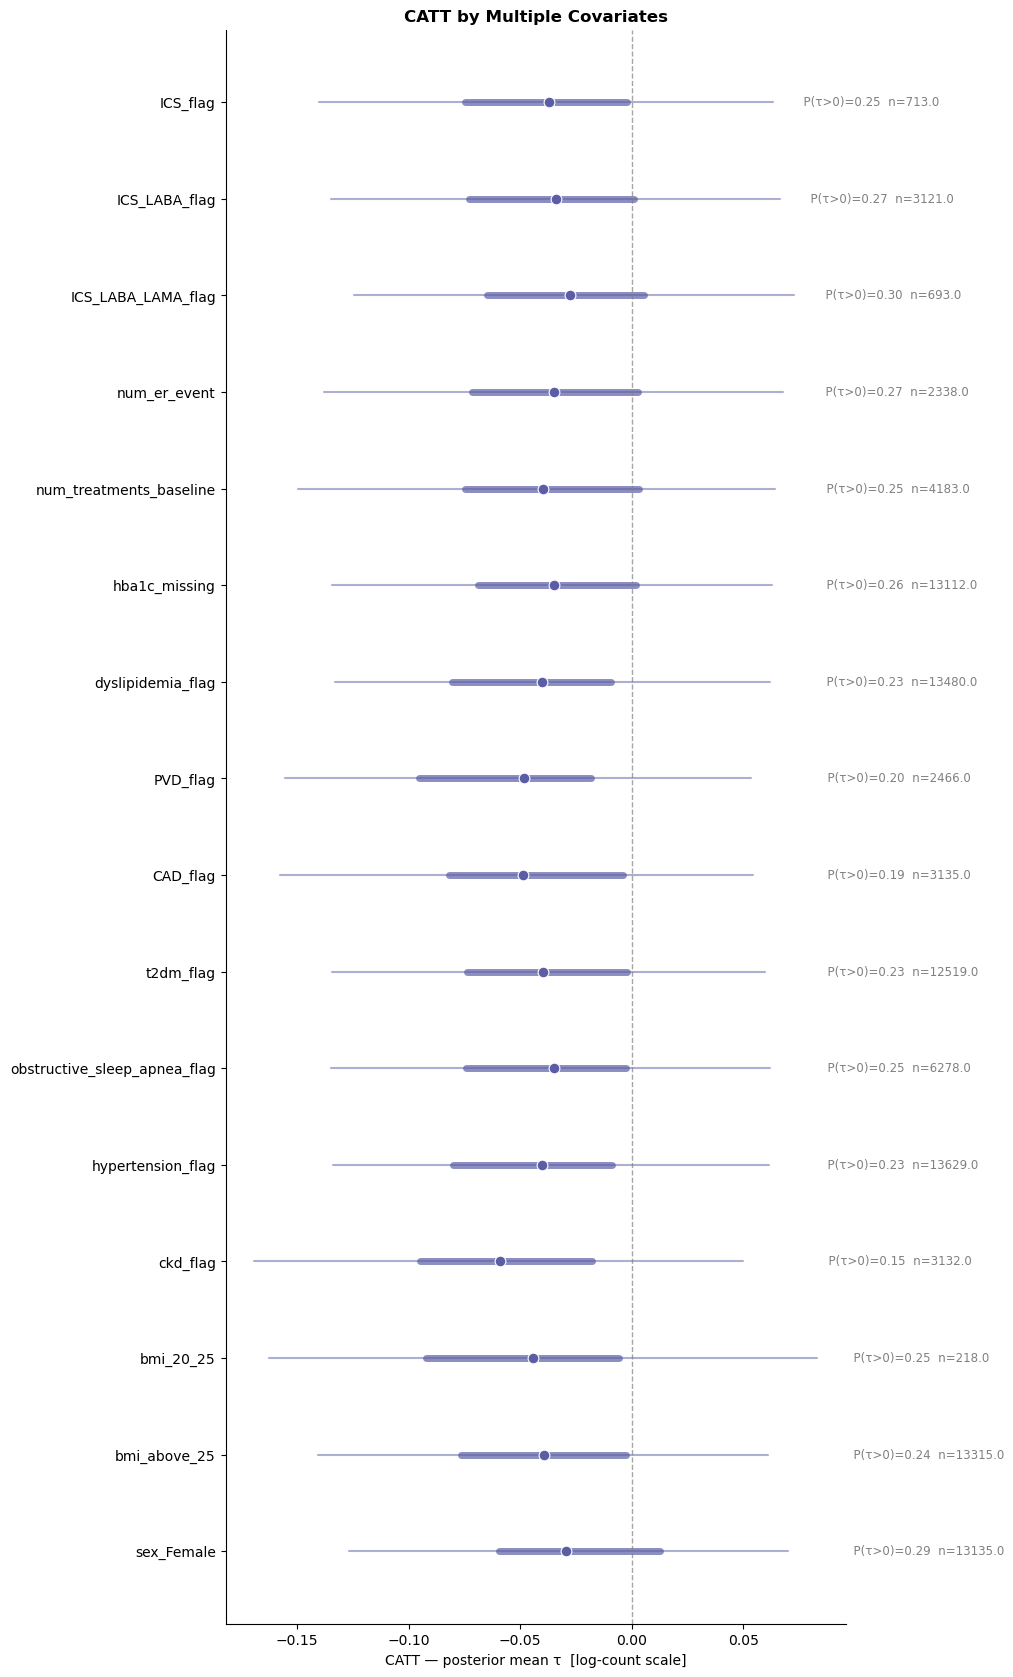

In [34]:
feature_list = [
    "ICS_flag", 
    "ICS_LABA_flag",
    "ICS_LABA_LAMA_flag",
    "num_er_event",
    "num_treatments_baseline",
    "hba1c_missing",
    "dyslipidemia_flag",
    "PVD_flag",
    "CAD_flag",
    "t2dm_flag",    
    "obstructive_sleep_apnea_flag",
    "hypertension_flag",
    "ckd_flag",
    "bmi_20_25",
    "bmi_above_25",
    "sex_Female",
    ]
ax, catt_df = plot_forest_multiple(
    trace_bcf, 
    X, 
    feature_names=feature_list, 
    ax=None)

## Decision Tree Proxy for CATTs that are clinically interpretable

In [35]:
# 1. Take the mean estimated treatment effect for each patient
catt_estimates = np.exp(trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values)
sorted_catt = np.sort(catt_estimates)
catt_rate_ratios = np.exp(catt_estimates)
y_proxy = catt_estimates

# Drop region columns if they exist, since they are not clinically interpretable
feature_names = X.columns

# 2. Fit a shallow Decision Tree to explain these effects using your covariates
# Max depth 3 keeps it clinically interpretable (8 subgroups max)
proxy_tree = DecisionTreeRegressor(max_depth=8)
proxy_tree.fit(X_tau, y_proxy)

# 3. Get the feature importance and visualize the rules
feature_importance = proxy_tree.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)
feature_importance_df.head(10).reset_index(drop=True)

,feature,importance
0,age,0.488901
1,region_South,0.167058
2,num_outpatient_event,0.101656
3,SABA_flag,0.086098
4,bmi_present,0.064645
5,sex_Female,0.041110
6,bmi_above_25,0.020159
7,region_Midwest,0.007795
8,gina_step,0.004763
9,T,0.003042


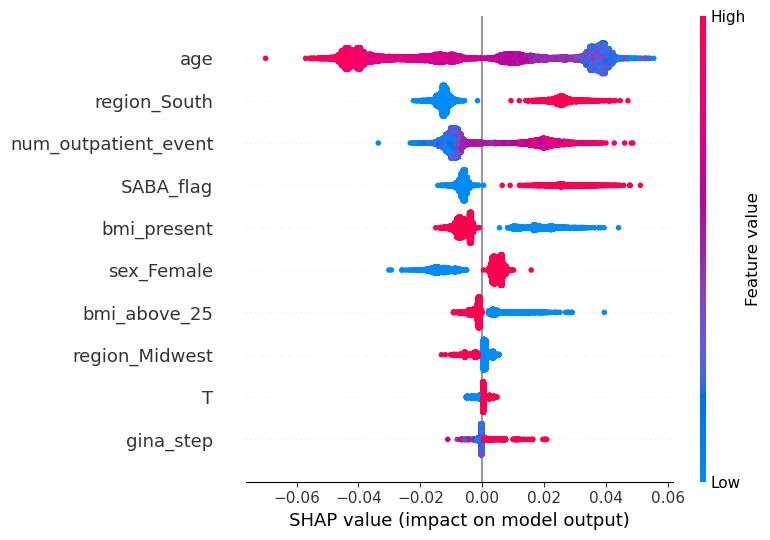

In [36]:
# SHAP values for the tree
import shap
explainer = shap.TreeExplainer(proxy_tree)
shap_values = explainer.shap_values(X_tau)

# Visualize the SHAP values
shap.summary_plot(shap_values, X_tau, feature_names=feature_names, max_display=10)
